In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# load the dataset
data = pd.read_csv('customer_churn.csv')

In [3]:
data.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [4]:
# check info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   object 
 9   region                 1000 non-null   object 
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 86.1+ KB


In [5]:
# checking for null values
data.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [6]:
# check columns names
data.columns

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn'],
      dtype='object')

In [7]:
# check value counts of target variable
data['churn'].value_counts()

churn
1    517
0    483
Name: count, dtype: int64

In [8]:
# check the categorical columns and numerical columns
categorical_cols = data.select_dtypes(include='object').columns
numerical_cols = data.select_dtypes(include=np.number).columns
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['gender', 'region'], dtype='object')
Numerical Columns: Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'churn'],
      dtype='object')


In [9]:
# check statistics summary
data.describe()


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


# Data Preprocessing 

In [10]:
# handled the missing values in the dataset
data['income'].value_counts()

income
254852.478291    20
53051.954538      1
39677.744822      1
51883.646802      1
47403.922636      1
                 ..
43317.462179      1
73693.582186      1
42157.099593      1
43697.197744      1
44407.502719      1
Name: count, Length: 932, dtype: int64

In [11]:
# find the mean , median and mode of the income column
mean_income = data['income'].mean()
median_income = data['income'].median()
mode_income = data['income'].mode()[0]
print("Mean Income:", mean_income)
print("Median Income:", median_income)
print("Mode Income:", mode_income)

Mean Income: 55354.41751318089
Median Income: 51298.8468120935
Mode Income: 254852.4782908424


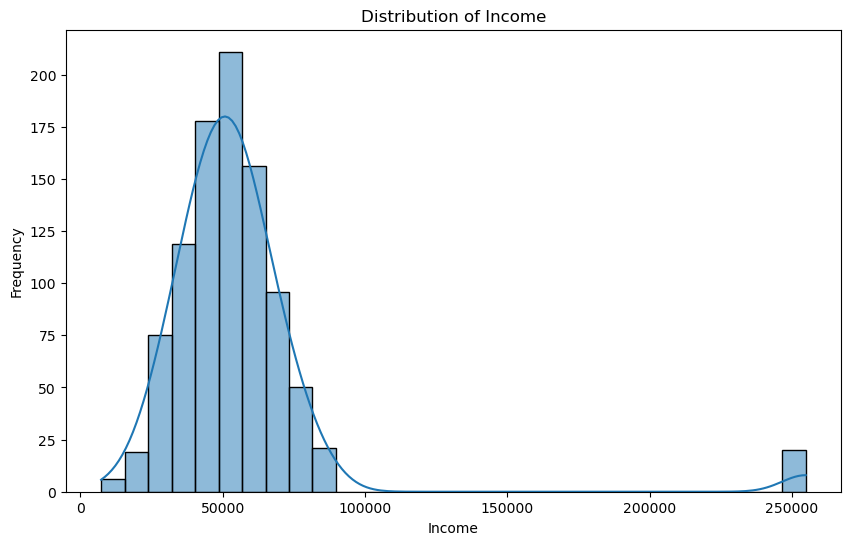

In [12]:
# distribution of income column
plt.figure(figsize=(10, 6))
sns.histplot(data['income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [13]:
# check the outlier ratio in the income column
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['income'] < lower_bound) | (data['income'] > upper_bound)]

# remove the outliers from the income column
data = data[(data['income'] >= lower_bound) & (data['income'] <= upper_bound)]

Text(0.5, 1.0, 'Box Plot of Income')

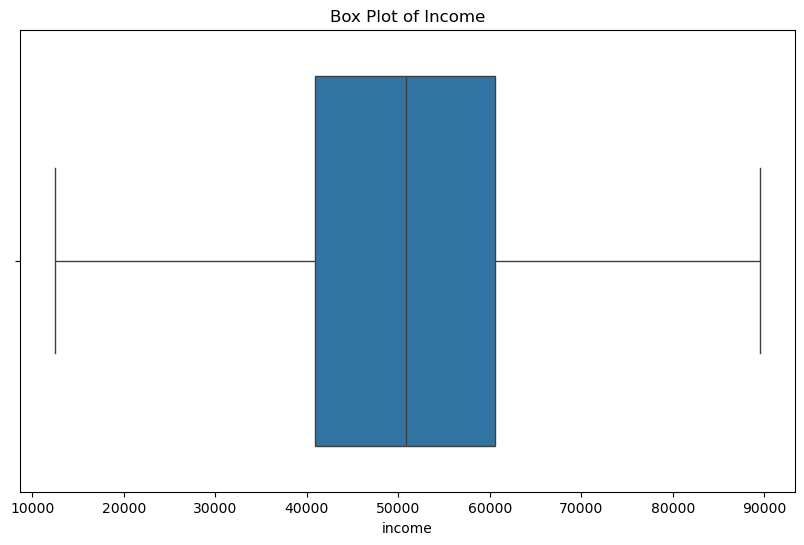

In [14]:
# make a box plot for the income column
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['income'])
plt.title('Box Plot of Income')

In [15]:
# find the median of the income column after removing the outliers
median_income = data['income'].median()
median_income

50891.36602950997

In [16]:
# using round function to round the median income to 6  decimal places
median_income = round(median_income, 7)
median_income

50891.3660295

In [17]:
# fill the income column missing values with the median income
data['income'].fillna(median_income, inplace=True)

C:\Users\Arunv\AppData\Local\Temp\ipykernel_28768\2619496049.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['income'].fillna(median_income, inplace=True)


In [18]:
# chck the missing values again
data.isnull().sum()

age                       0
income                    0
credit_score             45
transactions_month        0
avg_purchase_value       47
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

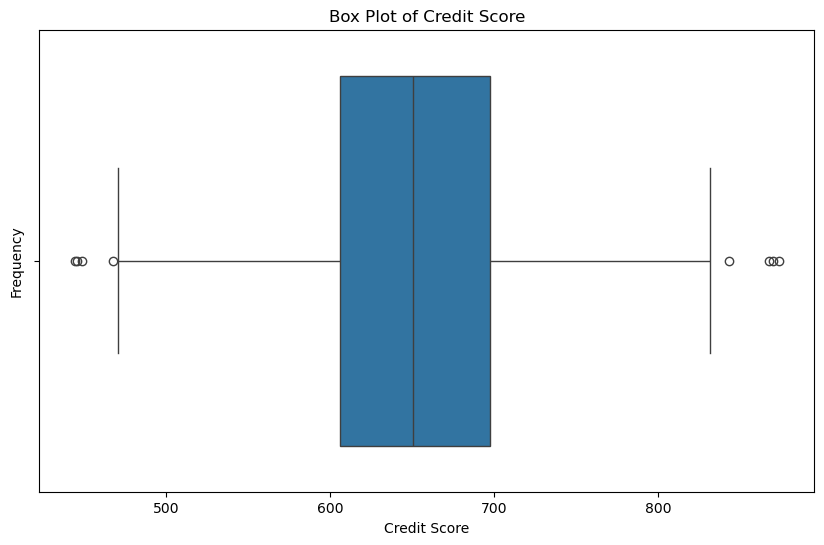

In [19]:
# check the outlier using box plot for credit score column
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['credit_score'])
plt.title('Box Plot of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [20]:
# remove the outliers from the credit score column
Q1 = data['credit_score'].quantile(0.25)
Q3 = data['credit_score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['credit_score'] >= lower_bound) & (data['credit_score'] <= upper_bound)]


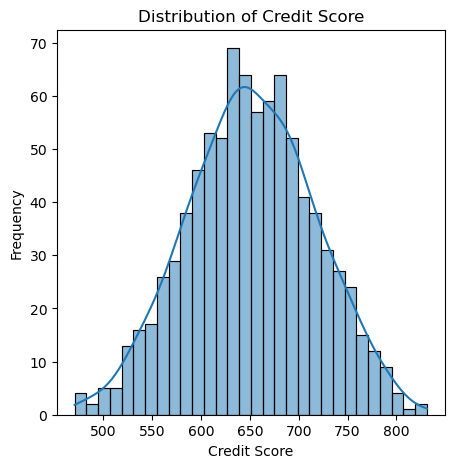

In [21]:
# check the distribustion of the credit score column
plt.figure(figsize=(5, 5))
sns.histplot(data['credit_score'], bins=30, kde=True)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [22]:
# find the mean of credit score column
mean_credit_score = data['credit_score'].mean()
mean_credit_score

np.float64(651.5158553240933)

In [23]:
# round the mean credit score to 6 decimal places
mean_credit_score = round(mean_credit_score, 7)
mean_credit_score

np.float64(651.5158553)

In [24]:
# handled missing value with mean value in the credit score column
data['credit_score'].fillna(mean_credit_score, inplace=True)

C:\Users\Arunv\AppData\Local\Temp\ipykernel_28768\1176154036.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['credit_score'].fillna(mean_credit_score, inplace=True)


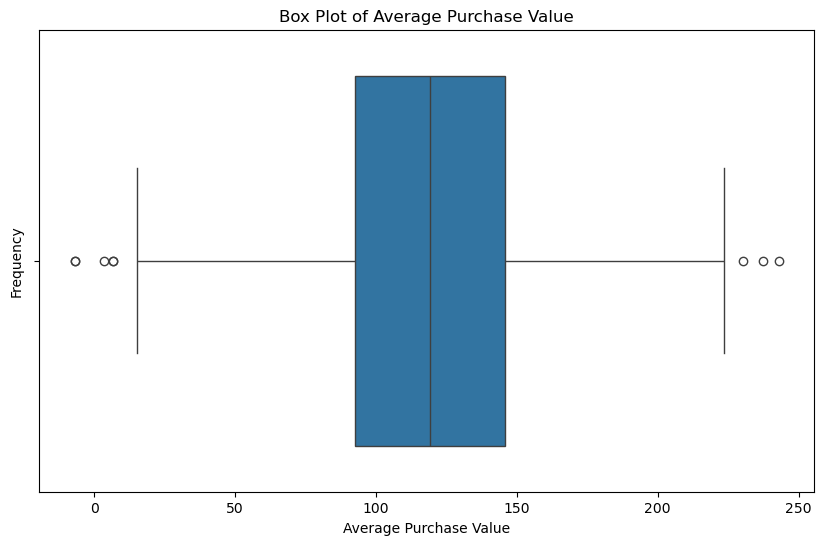

In [25]:
# boxplot of the avg_purchase_value column
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['avg_purchase_value'])
plt.title('Box Plot of Average Purchase Value')
plt.xlabel('Average Purchase Value')
plt.ylabel('Frequency')
plt.show()


In [26]:
# remove the outlier from the avg_purchase_value column
Q1 = data['avg_purchase_value'].quantile(0.25)
Q3 = data['avg_purchase_value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['avg_purchase_value'] >= lower_bound) & (data['avg_purchase_value'] <= upper_bound)]

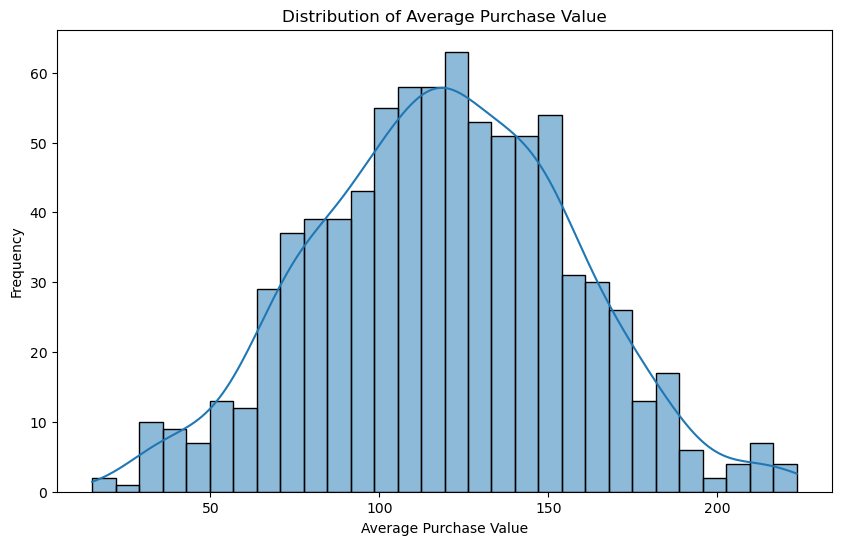

In [27]:
# check the distribution of the avg_purchase_value column
plt.figure(figsize=(10, 6))
sns.histplot(data['avg_purchase_value'], bins=30, kde=True)
plt.title('Distribution of Average Purchase Value')
plt.xlabel('Average Purchase Value')
plt.ylabel('Frequency')
plt.show()

In [28]:
# find the medium of the avg_purchase_value column
median_avg_purchase_value = data['avg_purchase_value'].median()

median_avg_purchase_value

119.24866736331325

In [29]:
# use round function to round the median average purchase value to 6 decimal places
median_avg_purchase_value = round(median_avg_purchase_value, 7)
median_avg_purchase_value

119.2486674

In [30]:
# fill the missing values with median on the avg_purchase_value column
data['avg_purchase_value'].fillna(median_avg_purchase_value, inplace=True)

C:\Users\Arunv\AppData\Local\Temp\ipykernel_28768\3310965904.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['avg_purchase_value'].fillna(median_avg_purchase_value, inplace=True)


In [31]:
# check for missing values
data.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [32]:
# check unique values in the categorical columns
for col in categorical_cols:
    print(f"Unique values in {col}: {data[col].unique()}")
    

Unique values in gender: ['Female' 'Male']
Unique values in region: ['East' 'North' 'South' 'West']


In [33]:
# replace the gender column values with 0 and 1
data['gender'] = data['gender'].replace({'Male': 0, 'Female': 1})

C:\Users\Arunv\AppData\Local\Temp\ipykernel_28768\3659453935.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['gender'] = data['gender'].replace({'Male': 0, 'Female': 1})


In [34]:
# convert the region column into numerical values using one hot encoding
data = pd.get_dummies(data, columns=['region'], drop_first=True)
data.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_North,region_South,region_West
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,1,False,False,False
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,1,True,False,False
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,0,False,True,False
7,56,63224.596354,738.380887,35,155.046767,181,71,3,0,1,False,False,True
8,36,49880.410380,611.369930,33,93.266192,314,33,4,0,1,False,False,True


In [35]:
# changge only boolean columns value into 0 and 1
boolean_cols = data.select_dtypes(include='bool').columns
for col in boolean_cols:
    data[col] = data[col].astype(int)

In [36]:
data.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_North,region_South,region_West
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,1,0,0,0
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,1,1,0,0
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,0,0,1,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,0,1,0,0,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,0,1,0,0,1


In [37]:
data.dtypes

age                        int64
income                   float64
credit_score             float64
transactions_month         int64
avg_purchase_value       float64
days_since_last_login      int64
tenure_months              int64
num_products               int64
gender                     int64
churn                      int64
region_North               int64
region_South               int64
region_West                int64
dtype: object

In [38]:
data.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_North,region_South,region_West
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,1,0,0,0
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,1,1,0,0
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,0,0,1,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,0,1,0,0,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,0,1,0,0,1


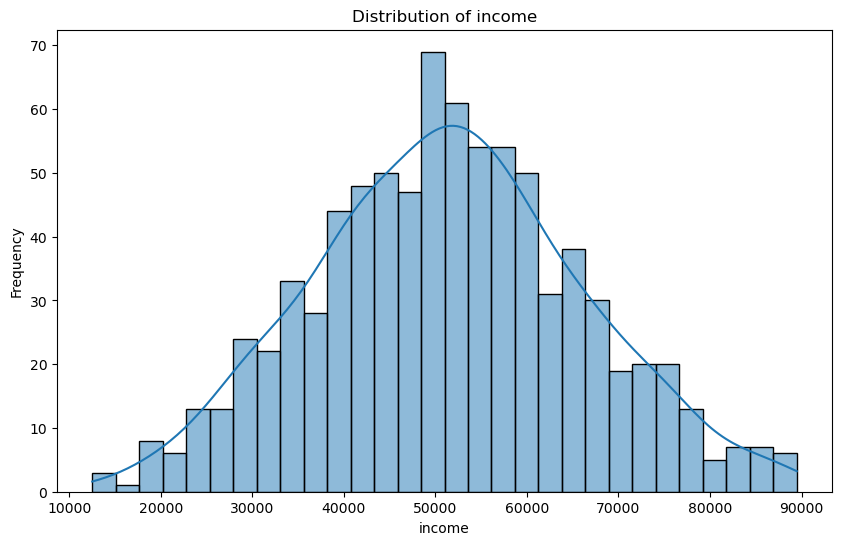

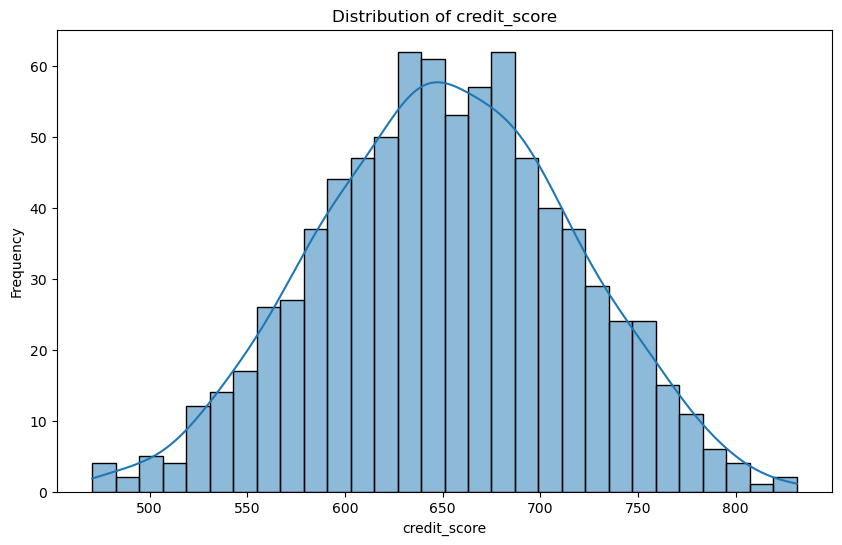

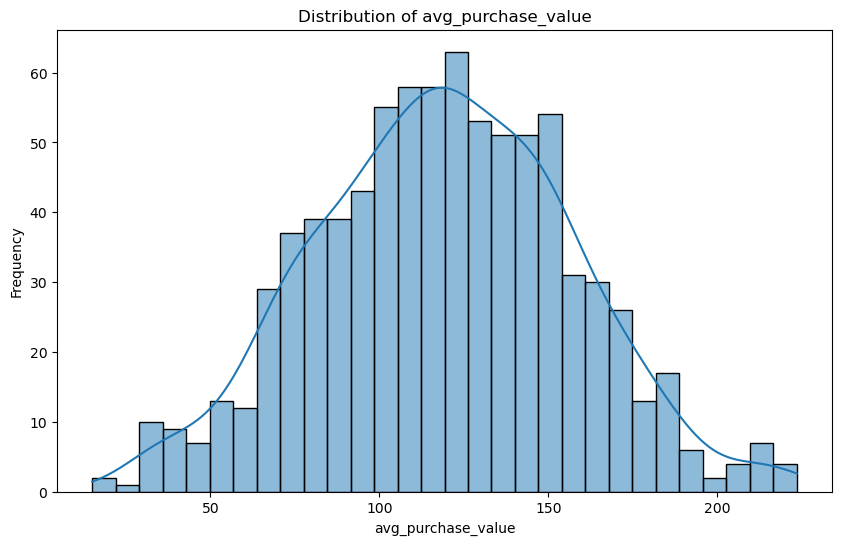

In [39]:
# check the distribution of the high scale numerical columns
high_scale_cols = ['income', 'credit_score', 'avg_purchase_value']

# plot the distribution of the high scale numerical columns
for col in high_scale_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [40]:
# scaled the data using min-max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data[high_scale_cols] = scaler.fit_transform(data[high_scale_cols])

data


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_North,region_South,region_West
1,69,0.526692,0.419787,41,0.570414,72,96,4,1,1,0,0,0
2,46,0.339658,0.540969,36,0.479527,155,88,3,0,1,1,0,0
3,32,0.209898,0.678376,29,0.666005,76,110,2,0,0,0,1,0
7,56,0.658844,0.742429,35,0.671623,181,71,3,0,1,0,0,1
8,36,0.485490,0.390240,33,0.375326,314,33,4,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,0.568796,0.779440,26,0.644168,120,93,4,0,0,0,0,1
996,64,0.314104,0.237530,40,0.140436,172,3,4,0,1,0,1,0
997,62,0.401799,0.631855,33,0.563296,3,52,2,0,0,0,0,0
998,35,0.627810,0.379758,49,0.275681,341,74,3,0,1,0,0,1


In [41]:
# divide data into features and target variable
X = data.drop('churn', axis=1)
y = data['churn']

In [42]:
# split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# train the logistic regression model
from sklearn.linear_model import LogisticRegression

# load the logistic regression model
model = LogisticRegression(C=10.0, solver='liblinear', max_iter=1000)

# fit the model on the training data
model.fit(X_train, y_train)

# make predictions on the test set
y_pred = model.predict(X_test)

# print the y_pred
print(y_pred)

[1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 0 0 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1
 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0
 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 1
 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 1
 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0]


In [44]:
# display both columns of y_test and y_pred in a dataframe
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results


,Actual,Predicted
741,1,1
207,0,1
79,1,0
200,1,1
336,0,1
...,...,...
355,1,0
254,1,0
549,1,0
937,0,0


In [45]:
# evaluate the model using classification report and confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[40 29]
 [44 52]]


In [46]:
# check accuracy score of the model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.5575757575757576


In [47]:
# check the precision, recall and f1 score of the model
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.58      0.52        69
           1       0.64      0.54      0.59        96

    accuracy                           0.56       165
   macro avg       0.56      0.56      0.56       165
weighted avg       0.57      0.56      0.56       165

